In [1]:
import numpy as np
import base
import matrix
import matplotlib.pyplot as plt


In [3]:
x=np.loadtxt('point_x.txt')
y=np.loadtxt('point_y.txt')
A = np.zeros((32,32))
for i in range(len(x)):
    for j in range(len(y)):
        A[i,j] = np.sqrt((x[i]-x[j])**2+ (y[i]-y[j])**2)
points = np.arange(len(A))

## Autocorrelation


In [4]:
dist,mc_hist,temp = base.traveling_MC_constDist_history(points,A,20000)

C:\Users\Win10\Computational physics\Projects\base.py:155: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


In [5]:
def autocorrelation(timeseries, mean=None):
    if mean is None:
        mean = timeseries.mean()
    fluctuations = timeseries-mean

    C = np.fft.ifft(np.fft.fft(fluctuations) * np.fft.ifft(fluctuations)).real
    return C/C[0]

def integrated_autocorrelation_time(timeseries, mean=None, until=None):
    steps = len(timeseries)
    if until is None:
        until = steps // 2
    Gamma = autocorrelation(timeseries, mean=mean)[:until]
    try:
        first_zero = np.where(Gamma <= 0)[0][0]
        return int(np.ceil(0.5 + Gamma[1:first_zero].sum()))
    except:
        # Gamma never hits 0.  So the autocorrelation spans ~ the whole ensemble.
        return steps # at least!

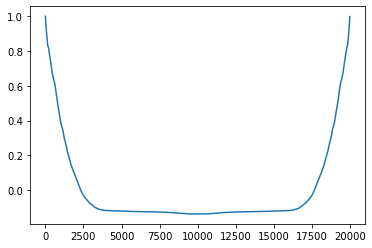

In [6]:
plt.plot(autocorrelation(dist))

In [7]:
print(integrated_autocorrelation_time(dist))

891


In [9]:
print(np.max(A))

2.449506832782463


# Different Temperatures and alphas

In [143]:
T = [1000.0, 100.0,25,10.0, 1.0, 0.1]
alpha = [1,0.99 , 0.95 ,0.9,0.8,0.5,0.1]


In [11]:
def what(a,b):
    c = a
    l = b
    k = f'Temp ={a},alpha = {b}'
    return c,l,k

In [30]:
store = []
wha = []
for temp in T:
    for a in alpha:
        store.append(base.traveling_MC_constDist(points,A,10000,starting_temp=temp,alpha=a)[1])
        #wha.append(what(temp,a))

C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: overflow encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: divide by zero encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: invalid value encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


In [31]:

T_1000 = np.array(store[0:7])
T_100 = np.array(store[7:14])
T_25 = np.array(store[14:21])
T_10 = np.array(store[21:28])
T_1 = np.array(store[28:35])
T_0_1 = np.array(store[35:])

In [32]:
result = np.array([T_1000[:,-1],T_100[:,-1],T_25[:,-1],T_10[:,-1],T_1[:,-1],T_0_1[:,-1]])
print(result)

[[32.81571227 10.2866088  10.30821202 10.17608368 10.49634443 10.10552
  10.63521185]
 [32.46022865 10.81409641 10.51937181 10.16996713 10.85931979 10.20165218
  10.44145647]
 [38.49954664 10.12043209 10.26558017 10.25431032 10.12654863 10.43787795
  10.5375186 ]
 [35.89207488 10.27226324 10.22568182 10.23102096 10.19686493 10.69398288
  10.41750652]
 [27.51786882 10.96907564 10.71169349 10.53741535 10.43583586 10.86404028
  10.6455451 ]
 [11.33990164 10.12490523 10.15505504 10.35245196 10.93974615 10.58628336
  10.2877209 ]]


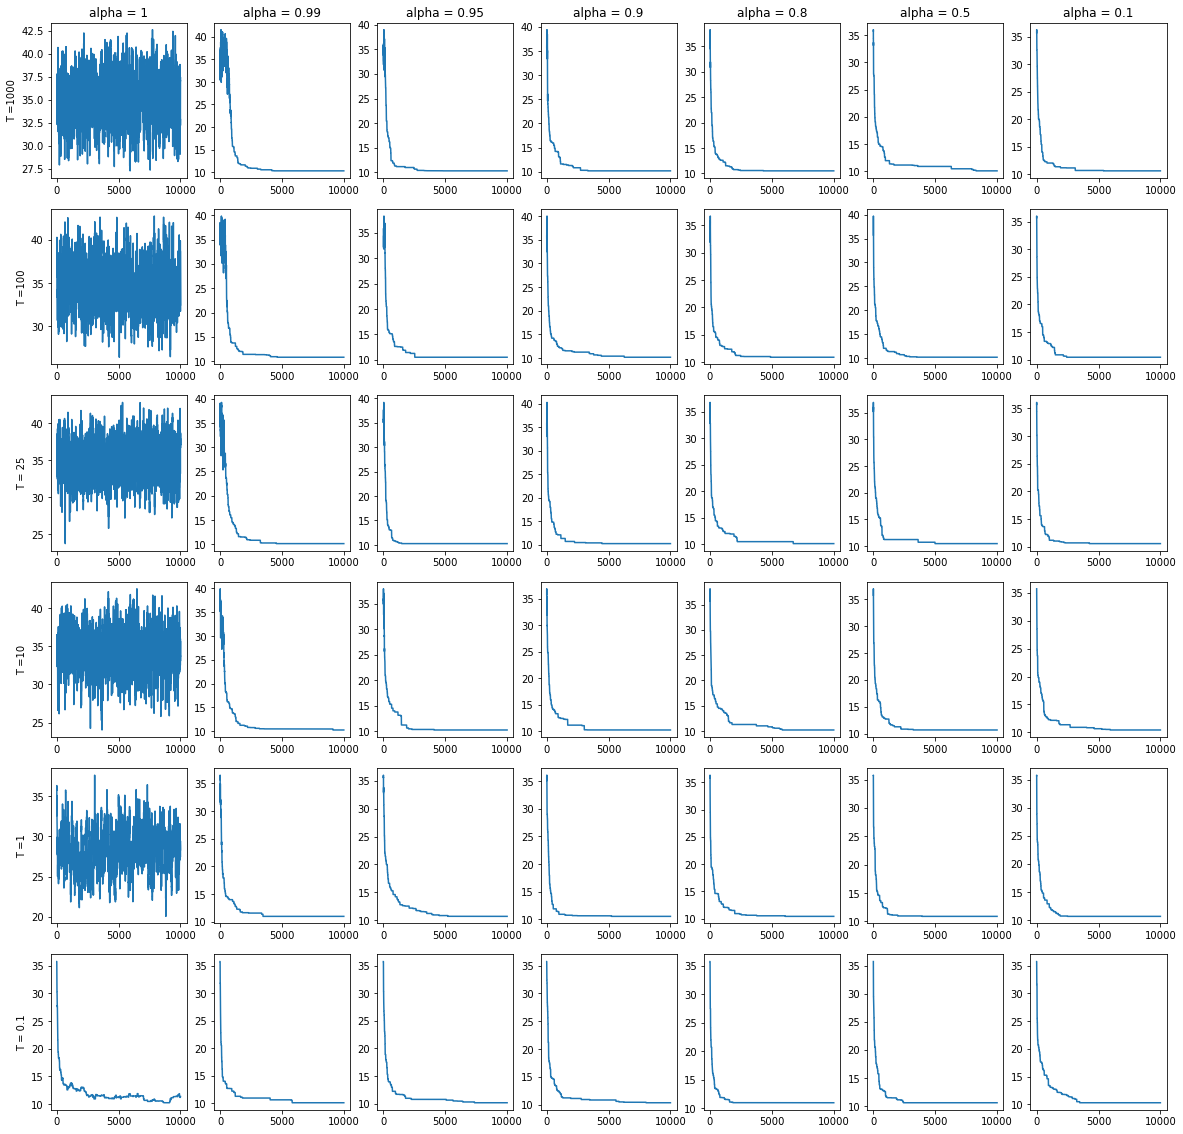

In [33]:
fig, (ax1000,ax100,ax_01,ax10,ax1,ax_1) = plt.subplots(6,7,figsize=(20,20))
for x in range(len(T_1000)):
    ax1000[x].plot(T_1000[x])
    ax100[x].plot(T_100[x])
    ax_01[x].plot(T_25[x])
    ax10[x].plot(T_10[x])
    ax1[x].plot(T_1[x])
    ax_1[x].plot(T_0_1[x])
    ax1000[x].set_title(f'alpha = {alpha[x]}')
ax1000[0].set_ylabel('T =1000')
ax100[0].set_ylabel('T =100')
ax_01[0].set_ylabel('T = 25')
ax10[0].set_ylabel('T =10')
ax1[0].set_ylabel('T =1')
ax_1[0].set_ylabel('T = 0.1')

plt.show()

As long as $\alpha < 1$ we get a samll distance as result.

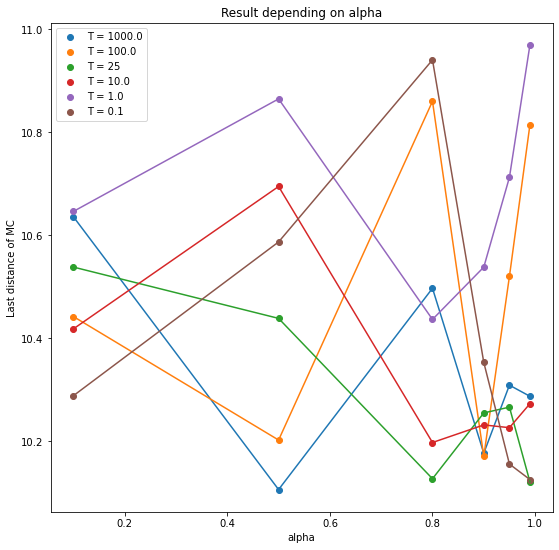

In [48]:
fig, ax = plt.subplots(figsize=(9,9))
for x in range(len(T)):
    ax.scatter(alpha[1:],result[x][1:],label =f'T = {T[x]}')
    ax.plot(alpha[1:],result[x][1:])#,label =f'T = {T[x]}')
    ax.legend()
    ax.set_ylabel('Last distance of MC')
    ax.set_xlabel('alpha')
    ax.set_title('Result depending on alpha')

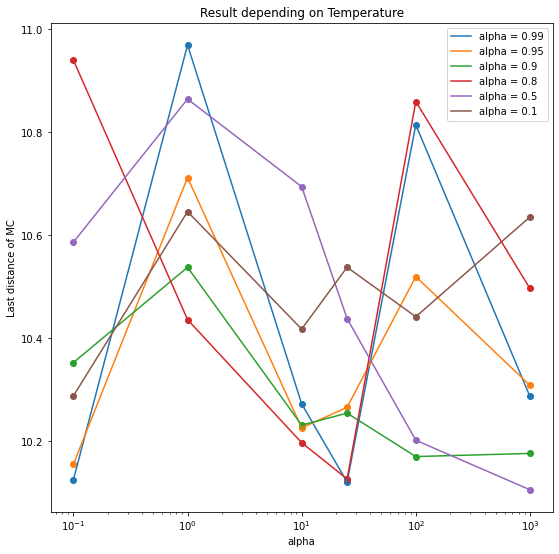

In [45]:
fig, ax = plt.subplots(figsize=(9,9))
for x in range(1,len(alpha)):
    ax.plot(T,result.T[x],label =f'alpha = {alpha[x]}')
    ax.scatter(T,result.T[x])#,label =f'alpha = {alpha[x]}')
    ax.legend()
    ax.set_ylabel('Last distance of MC')
    ax.set_xlabel('alpha')
    ax.set_title('Result depending on Temperature')
    ax.set_xscale('log')

# Different Temperatures and alphas with Insertion start -> start in local minimum

In [53]:
import tsp
points2=tsp.nearest_Insertion(A)[:-1]
print(points2)

[21 29 16  2 22  6  7 15 24 13 19 30 14  0 27 31 10 26  5 28 25 17 11  3
 23  4 20 18  8 12  9  1]


In [54]:
print(base.totalTravelDist(points2,A))

10.868052183598449


In [70]:
store = []
wha = []
for temp in T:
    for a in alpha:
        store.append(base.traveling_MC_constDist(points2,A,10000,starting_temp=temp,alpha=a)[1])
T_1000 = np.array(store[0:7])
T_100 = np.array(store[7:14])
T_25 = np.array(store[14:21])
T_10 = np.array(store[21:28])
T_1 = np.array(store[28:35])
T_0_1 = np.array(store[35:])
result = np.array([T_1000[:,-1],T_100[:,-1],T_25[:,-1],T_10[:,-1],T_1[:,-1],T_0_1[:,-1]])

C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: overflow encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: divide by zero encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: invalid value encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


In [71]:
print(result)

[[31.71290396 10.23102096 10.48273957 11.27831624 10.33142332 10.33057615
  10.82516591]
 [34.22462422 10.2866088  10.29686412 10.53501039 10.98728527 10.33725594
  10.9203984 ]
 [30.26897374 10.47602127 10.37725119 10.77662848 10.66416911 10.17583629
  10.85450797]
 [29.83413047 10.8228981  10.22699193 10.47978893 10.27117248 10.69790771
  10.69790771]
 [27.39743612 10.53741535 10.59895005 10.97185187 10.62867121 10.44714994
  10.69790771]
 [11.55281784 10.69790771 10.69790771 10.68863572 10.69790771 10.44714994
  10.69790771]]


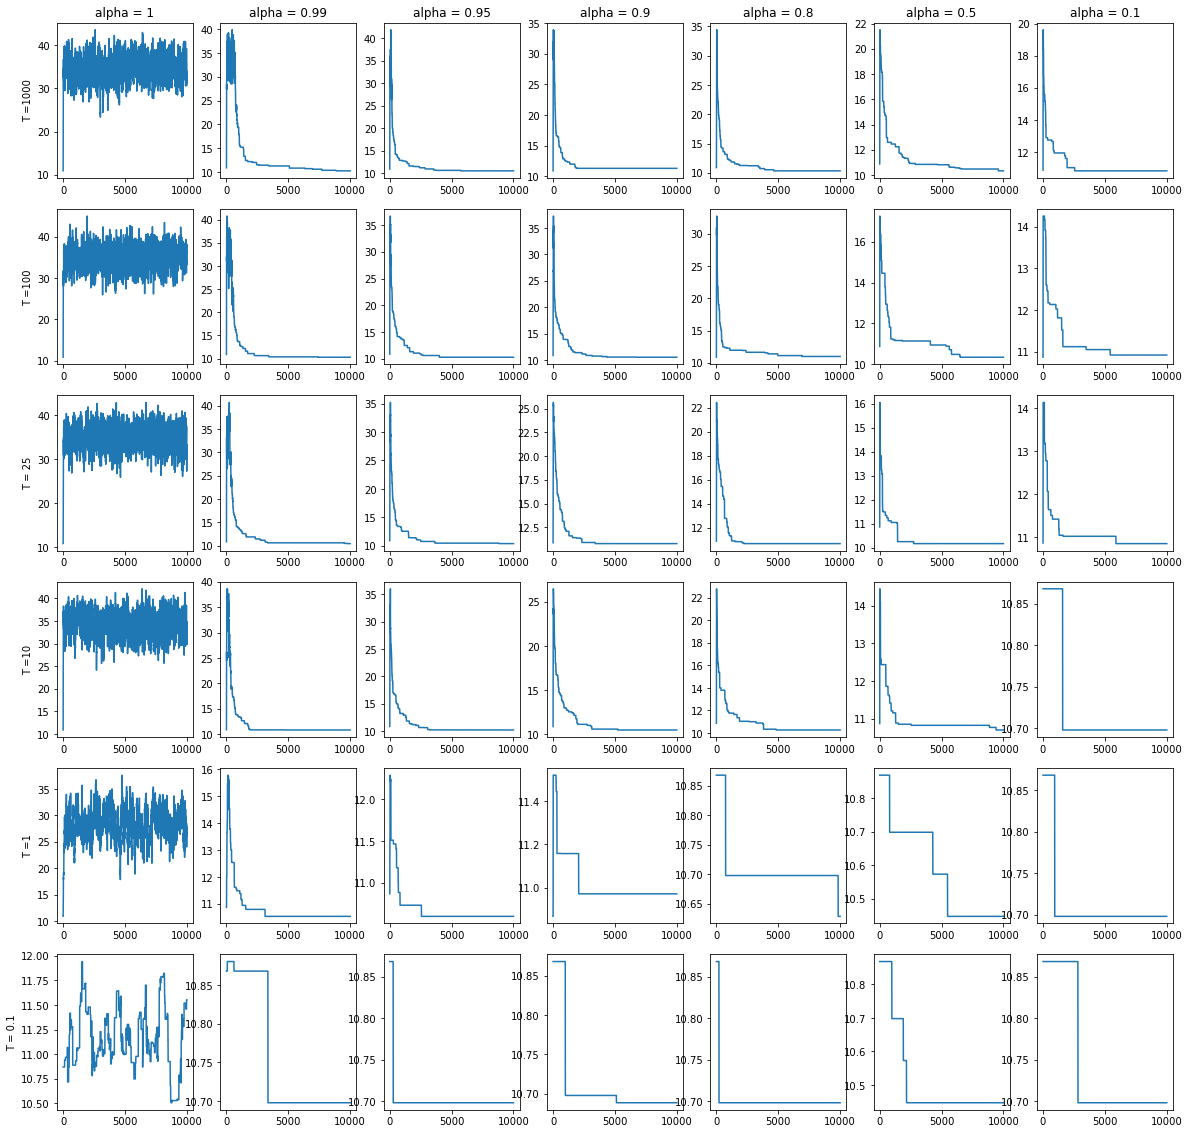

In [72]:
fig, (ax1000,ax100,ax_01,ax10,ax1,ax_1) = plt.subplots(6,7,figsize=(20,20))
for x in range(len(T_1000)):
    ax1000[x].plot(T_1000[x])
    ax100[x].plot(T_100[x])
    ax_01[x].plot(T_25[x])
    ax10[x].plot(T_10[x])
    ax1[x].plot(T_1[x])
    ax_1[x].plot(T_0_1[x])
    ax1000[x].set_title(f'alpha = {alpha[x]}')
ax1000[0].set_ylabel('T =1000')
ax100[0].set_ylabel('T =100')
ax_01[0].set_ylabel('T = 25')
ax10[0].set_ylabel('T =10')
ax1[0].set_ylabel('T =1')
ax_1[0].set_ylabel('T = 0.1')

plt.show()

We see for high alphas<1 and high T we have more time to exit local Minimum

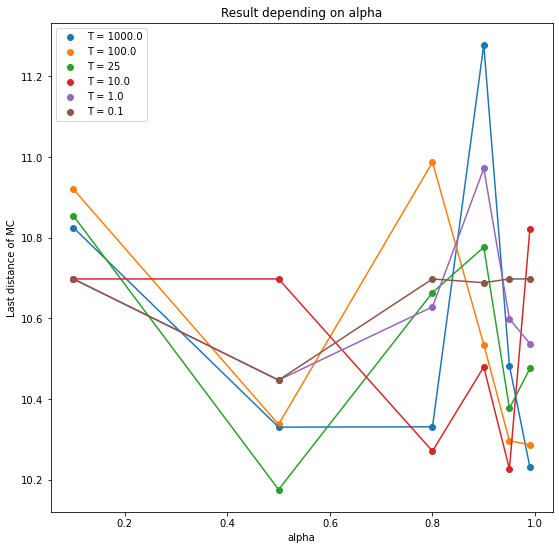

In [73]:
fig, ax = plt.subplots(figsize=(9,9))
for x in range(len(T)):
    ax.scatter(alpha[1:],result[x][1:],label =f'T = {T[x]}')
    ax.plot(alpha[1:],result[x][1:])#,label =f'T = {T[x]}')
    ax.legend()
    ax.set_ylabel('Last distance of MC')
    ax.set_xlabel('alpha')
    ax.set_title('Result depending on alpha')

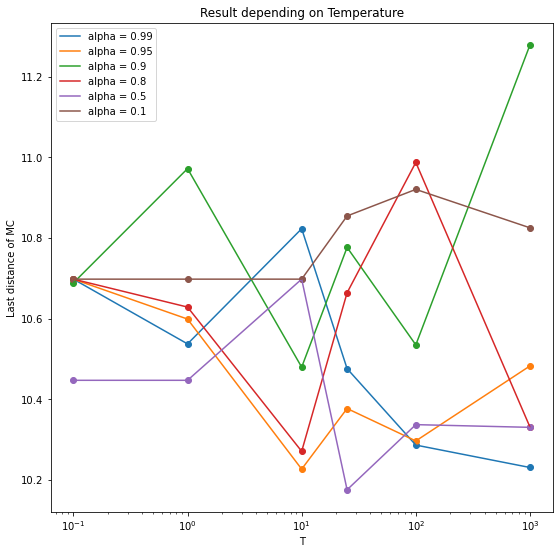

In [75]:
fig, ax = plt.subplots(figsize=(9,9))
for x in range(1,len(alpha)):
    ax.plot(T,result.T[x],label =f'alpha = {alpha[x]}')
    ax.scatter(T,result.T[x])#,label =f'alpha = {alpha[x]}')
    ax.legend()
    ax.set_ylabel('Last distance of MC')
    ax.set_xlabel('T')
    ax.set_title('Result depending on Temperature')
    ax.set_xscale('log')

# Autocorrelation

Text(0, 0.5, 'T = 0.01')

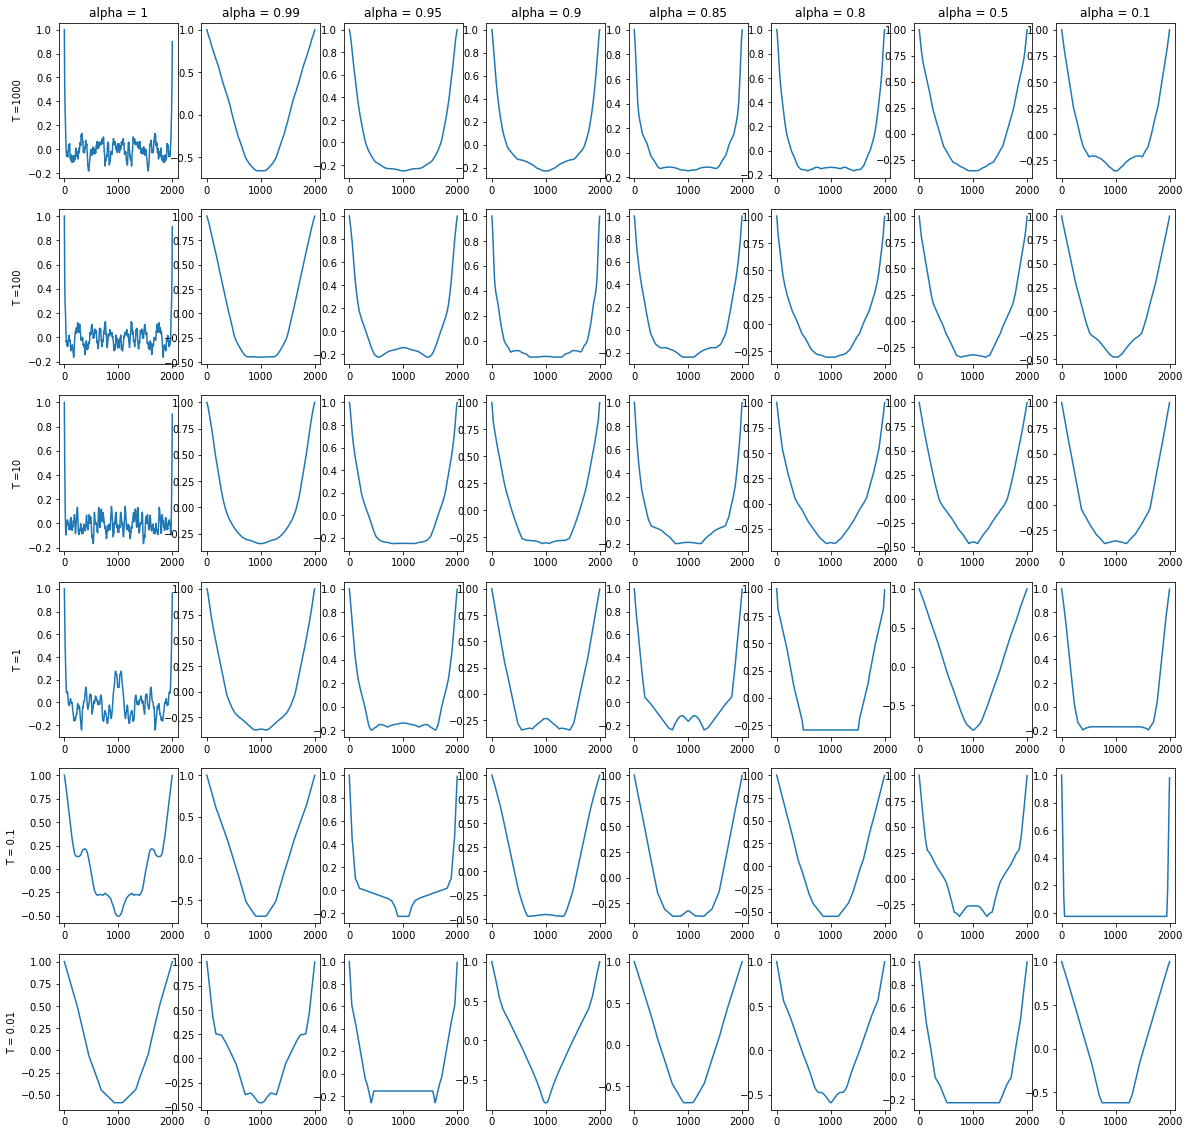

In [29]:
fig, (ax1000,ax100,ax10,ax1,ax_1,ax_01) = plt.subplots(6,8,figsize=(20,20))
for x in range(len(T_1000)):
    ax1000[x].plot(autocorrelation(T_1000[x]))
    ax100[x].plot(autocorrelation(T_100[x]))
    ax10[x].plot(autocorrelation(T_10[x]))
    ax1[x].plot(autocorrelation(T_1[x]))
    ax_1[x].plot(autocorrelation(T_0_1[x]))
    ax_01[x].plot(autocorrelation(T_0_01[x]))
    ax1000[x].set_title(f'alpha = {alpha[x]}')
ax1000[0].set_ylabel('T =1000')
ax100[0].set_ylabel('T =100')
ax10[0].set_ylabel('T =10')
ax1[0].set_ylabel('T =1')
ax_1[0].set_ylabel('T = 0.1')
ax_01[0].set_ylabel('T = 0.01')

# Reuse previous result to leave local minma

In [60]:
def mc_reuse(points,distance,steps,temp,alpha,tries):
    minimal_dist = len(A)* np.max(A)
    last_value =[]
    for x in range(tries):
        dist,mc,temps = base.traveling_MC_constDist_history(points,A,steps, starting_temp=temp,alpha =alpha)
        if dist[-1]<minimal_dist:
            minimal_dist=dist[-1]
            end_dist = dist
            end_mc = mc
            end_temps = temps
            points = end_mc[-1][:-1].astype(int)
        last_value = np.append(last_value,dist[-1])
    return end_dist,end_mc,end_temps,last_value
        

In [76]:
d_r,mc_r,t_r,last_value= mc_reuse(points,A,10000,100,0.95,30)

C:\Users\Win10\Computational physics\Projects\base.py:155: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


In [96]:
print(len(last_value))

30


10.096620931124356
10.132703639772737


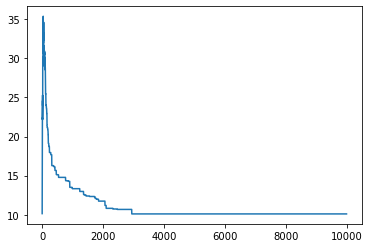

In [77]:
plt.plot(d_r)
print(d_r[-1])
print(base.totalTravelDist(mc_r[0].astype(int),A))

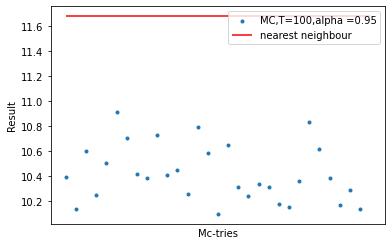

In [87]:
plt.scatter (np.arange(len(last_value)),last_value,marker='.', label='MC,T=100,alpha =0.95')
plt.hlines(base.totalTravelDist(tsp.nearest_Insertion(A),A),0,30,color='red',label='nearest neighbour')
plt.xlabel('Mc-tries')
plt.xticks([])
plt.ylabel('Result')
plt.legend()
plt.show()

# Time comparison

In [88]:
%%timeit
nn=tsp.Nearest_Neighbor_all_start(points,A)

68.2 ms ± 2.63 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [89]:
%%timeit
dn=tsp.Double_side_Nearest_Neighbor_all_start(points,A)

77.5 ms ± 5.04 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [90]:
%%timeit
nI=tsp.nearest_Insertion(A)

62 ms ± 1.11 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [95]:
%%timeit
tsp.christofides_all(A)

2.54 s ± 187 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [91]:
%%timeit
base.traveling_MC_constDist(points,A,10000,100,0.95)

C:\Users\Win10\Computational physics\Projects\base.py:119: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


1.16 s ± 140 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [92]:
%%timeit
mc_reuse(points,A,5000,100,0.95,30)

C:\Users\Win10\Computational physics\Projects\base.py:155: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


15.9 s ± 1.12 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [94]:
nn=tsp.Nearest_Neighbor_all_start(points,A)
dn=tsp.Double_side_Nearest_Neighbor_all_start(points,A)
nI=tsp.nearest_Insertion(A)
c=tsp.christofides_all(A)

In [95]:
print(nn[1])
print(dn[1])
print(base.totalTravelDist(nI,A))
print(base.totalTravelDist(c,A))
print(base.totalTravelDist(base.traveling_MC_constDist(points,A,10000,100,0.95)[0],A))
print(d_r[-1])

10.684930228433776
11.242632707281546
11.012077891473592
11.719620385458168
10.131021771456982
10.096620931124356


# Averages

In [112]:


resultstore =[]
tries = 30
for z in range(tries):
    store = []
    for temp in T:
        for a in alpha:
            store.append(base.traveling_MC_constDist(points,A,5000,starting_temp=temp,alpha=a)[1])
    T_1000 = np.array(store[0:7])
    T_100 = np.array(store[7:14])
    T_25 = np.array(store[14:21])
    T_10 = np.array(store[21:28])
    T_1 = np.array(store[28:35])
    T_0_1 = np.array(store[35:])
    result = np.array([T_1000[:,-1],T_100[:,-1],T_25[:,-1],T_10[:,-1],T_1[:,-1],T_0_1[:,-1]])
    resultstore = np.append(resultstore,result)
r_mc = resultstore.reshape(tries,len(T),len(alpha))

In [123]:
#print(r_mc)

In [115]:
mean_result_mc=r_mc.mean(axis=0)
std_result_mc =r_mc.std(axis=0)
print(mean_result_mc)
print(std_result_mc)

[[35.44815928 10.61521352 10.59330036 10.55921665 10.56985721 10.52950738
  10.63886795]
 [36.01878711 10.55899576 10.52878622 10.56233091 10.62377371 10.60905963
  10.64375179]
 [33.68176484 10.63574106 10.49026258 10.54906637 10.52276162 10.56601284
  10.56306903]
 [33.46383788 10.63864424 10.51316101 10.58432086 10.47097109 10.55338256
  10.5617609 ]
 [27.79504167 10.58263943 10.53772412 10.54784244 10.63082953 10.52519034
  10.66610868]
 [11.2360232  10.50149763 10.53534215 10.64650965 10.60063271 10.56333235
  10.67899408]]
[[2.34553192 0.30764264 0.34144214 0.25424479 0.23172012 0.23328145
  0.34768143]
 [2.43389597 0.24805278 0.27231184 0.33566272 0.30602298 0.35546188
  0.29928465]
 [2.80083653 0.33143999 0.26781966 0.34163029 0.23121749 0.32484212
  0.35565275]
 [2.37539155 0.30983231 0.24942092 0.29618209 0.2360169  0.35051804
  0.33161336]
 [2.72974293 0.35279588 0.24514501 0.35591778 0.3039808  0.27350216
  0.31956286]
 [0.44642715 0.35894738 0.24235182 0.26017816 0.3160204

In [125]:
min_res = 80*np.ones((len(T),len(alpha)))
for x in range(tries):
    for s in range(len(min_res)):
        for a in range(len(min_res.T)):
            if r_mc[x,s,a] < min_res[s,a]:
                min_res[s,a] = r_mc[x,s,a]
            

In [126]:
print(min_res)

[[30.21901455  9.98026319 10.13647145 10.18674009 10.15505504 10.14032336
   9.98026319]
 [31.29193821 10.04610635 10.12490523  9.98026319  9.98026319 10.04610635
   9.98026319]
 [26.69931836 10.01430205 10.10999314 10.12490523 10.13270364  9.98026319
  10.04610635]
 [29.54342123 10.16996713  9.98026319 10.13270364 10.04610635  9.98026319
  10.13102177]
 [22.07266194 10.09662093 10.10999314 10.04610635 10.04610635 10.16996713
  10.18674009]
 [10.56022875  9.98026319 10.10999314 10.1153179  10.12490523 10.13717678
  10.24302449]]


In [130]:
count_min_res = np.zeros((7,8))
for x in range(tries):
    for q in range(len(min_res)):
        for a in range(len(min_res.T)):
            if r_mc[x,q,a] == np.min(min_res):
                count_min_res[q,a] = count_min_res[q,a]+1

In [131]:
print(count_min_res)

[[0. 1. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 2. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


In [157]:
print(mean_result_mc[:,1:].mean())

10.57495717675874


In [144]:
print(len(alpha),len(T),len(mean_result_mc[:,1:]))

7 6 6


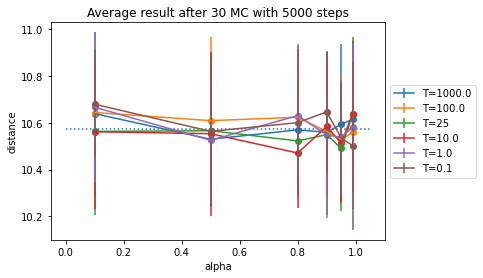

In [182]:
for z in range(len(T)):
    plt.errorbar(alpha[1:],mean_result_mc[z,1:],yerr=std_result_mc[z,1:], label=f'T={T[z]}')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.scatter(alpha[1:],mean_result_mc[z,1:])
plt.hlines(mean_result_mc[:,1:].mean(),0,1.05, linestyle =':')
plt.title('Average result after 30 MC with 5000 steps')
plt.xlabel('alpha')
plt.ylabel('distance')
plt.show()

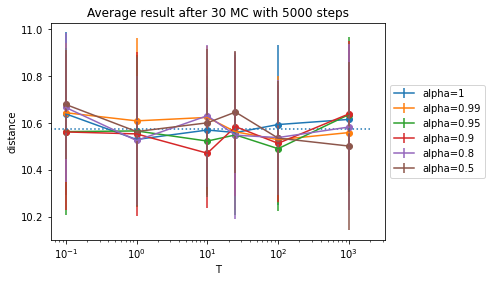

In [183]:
for z in range(len(T)):
    plt.errorbar(T[:],mean_result_mc[z,1:].T,yerr=std_result_mc[z,1:].T, label=f'alpha={alpha[z]}')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.scatter(T[:],mean_result_mc[z,1:].T)
plt.hlines(mean_result_mc[:,1:].mean(),0,2000, linestyle =':')
plt.title('Average result after 30 MC with 5000 steps')
plt.xlabel('T')
plt.xscale('log')
plt.ylabel('distance')
plt.show()

In [174]:
print(mean_result_mc[:,1:].T-mean_result_mc[:,1:])

[[ 0.         -0.0343046   0.07652441  0.06878703  0.05313205 -0.13737031]
 [ 0.0343046   0.         -0.07206833 -0.1106127  -0.0713355  -0.10840965]
 [-0.07652441  0.07206833  0.          0.06155924 -0.01817041  0.08344063]
 [-0.06878703  0.1106127  -0.06155924  0.          0.07744697  0.03887181]
 [-0.05313205  0.0713355   0.01817041 -0.07744697  0.         -0.10277633]
 [ 0.13737031  0.10840965 -0.08344063 -0.03887181  0.10277633  0.        ]]


In [185]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML

In [187]:
x=np.loadtxt('point_x.txt')
y=np.loadtxt('point_y.txt')

In [189]:
fig, ax = plt.subplots(figsize=(9,9))

def init():
    ax.clear()


def update(framenr):
    speed =25
    ax.clear() # clear the old plot
    

    ax.axes.xaxis.set_ticks([]) 
    ax.axes.yaxis.set_ticks([])
    
    # Plots
    ax.plot(2,2)
    ax.plot(0,0)
    ax.scatter(x, y,s = 4, label = "Points" , color = 'blue') 
    mcaktu = mc_r[framenr*speed].astype(int)
    ax.plot(x[mcaktu],y[mcaktu],color = 'yellow')
    if framenr>0:
        ax.plot(0,0,color='cyan',label='MC:10000 steps')
    box = ax.get_position()
    ax.set_position([box.x0, box.y0,0.5, box.height])
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.set_title('MC:Reuse result from Mc')
    for i, txt in enumerate(points):
        ax.annotate(i, (x[i], y[i]+0.05))

anim = FuncAnimation(
    fig, 
    update,
    frames=np.arange(0,250),
    init_func=init,
    repeat= False,
    blit=False)
fig.canvas.draw()
anim.event_source.stop()
#anim.save("mc_christo_20_steps.gif")
plt.close(fig)

# Show Animation directly in th Notebook

HTML(anim.to_jshtml())
anim.to_jshtml()
#print(anim.to_html5_video())
with open("mc_reuse.html", "w") as f:
    print(anim.to_jshtml(), file=f)